<a href="https://colab.research.google.com/github/mireillejb/FallDetectionSys/blob/main/article4_anticipate_detect_falls_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch==2.6.0+cu124 --extra-index-url https://download.pytorch.org/whl/cu124

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 146.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 244.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 137.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 77.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 98.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 124.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 115.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 94.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.1/150.1 MB 109.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 90.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━

In [2]:
import torch
print("torch:", torch.__version__)
print("torch CUDA build:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))
print("Compute capability:", torch.cuda.get_device_capability(0))
print("Supported archs:", torch.cuda.get_arch_list())

torch: 2.6.0+cu124
torch CUDA build: 12.4
GPU: Tesla P100-PCIE-16GB
Compute capability: (6, 0)
Supported archs: ['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']


# 🎓 Joint Anticipation & Detection of Falls — v11
## Thèse de Doctorat — Année 3

### Changes vs v10 (Config B only — A stays identical) :
- **Phase 1 Config B** : 100 epochs instead of 50 (more anticipation learning)
- **ant_embed Config B** : 512→256→256 instead of 512→128 (more capacity)
- **p_dist Config B** : full softmax (2 values) instead of p_preFall (1 value)
- **Detection input Config B** : 770 instead of 641
- **Config A** : unchanged (50+150 epochs, 512 input)

### Why still scientifically fair :
The extra Phase 1 epochs in B are for anticipation only — A has no
anticipation task so more Phase 1 epochs would not help it.
The extra capacity in ant_embed only exists in B.
Both share the same encoder, same CASIA prior, same Phase 2.

### Comparison :
```
Config A : z(512) → DetectionHead(512→2) → NON-FALL/FALL
Config B : z(512) → ant_embed(512→256→256) → e_A(256)
                  → ant_head → logits_A → p_dist(2)
                  → DetectionHead([z||e_A||p_dist]=770→2)
```

In [3]:
# ============================================================
# CELL 1 — Imports
# ============================================================
import os, pickle, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import (
    classification_report, f1_score, confusion_matrix
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'✅ Libraries importées')
print(f'   PyTorch : {torch.__version__}')
print(f'   Device  : {DEVICE}')

✅ Libraries importées
   PyTorch : 2.6.0+cu124
   Device  : cuda


In [4]:
# ============================================================
# CELL 2 — Constantes + Feature extraction
# ============================================================
WINDOW_SIZE    = 15
PREDICT_STEPS  = 8
STRIDE_CASIA   = 5
STRIDE_LE2I    = 3
FPS_LE2I       = 25
N_JOINTS       = 17
PRE_FALL_FRAMES = 20   # frames avant l'impact = PRE-FALL


def extract_features(kp_seq):
    """
    (T, 17, 2 ou 3) -> (T, 34) normalise hip-centered.
    """
    xy         = kp_seq[:, :, :2].copy().astype(np.float32)
    hip_center = (xy[:, 11, :] + xy[:, 12, :]) / 2.0
    rel        = xy - hip_center[:, np.newaxis, :]
    torso_h    = np.linalg.norm(
        xy[:, 0, :] - hip_center, axis=1, keepdims=True)
    torso_h    = np.where(torso_h < 1e-6, 1.0, torso_h)
    rel        = rel / torso_h[:, np.newaxis, :]
    return rel.reshape(len(kp_seq), -1).astype(np.float32)


print(f'✅ Constantes définies')
print(f'   WINDOW_SIZE={WINDOW_SIZE} | PRE_FALL_FRAMES={PRE_FALL_FRAMES}')
print(f'   FPS_LE2I={FPS_LE2I}')

✅ Constantes définies
   WINDOW_SIZE=15 | PRE_FALL_FRAMES=20
   FPS_LE2I=25


In [5]:
# ============================================================
# CELL 3 — Download datasets
# ============================================================
!pip install kagglehub --quiet
import kagglehub

path_casia = kagglehub.dataset_download('mireillejabbour/casia-b-simcc')
path_le2i  = kagglehub.dataset_download('tuyenldvn/falldataset-imvia')

print(f'✅ CASIA-B SimCC : {path_casia}')
print(f'✅ Le2i          : {path_le2i}')

# Vérifier la structure Le2i
root_le2i = Path(path_le2i)
print(f'\n📁 Structure Le2i :')
for item in sorted(root_le2i.iterdir())[:8]:
    print(f'   {item.name}/')
    if item.is_dir():
        sub = list(item.iterdir())[:3]
        for s in sub:
            print(f'      {s.name}')

✅ CASIA-B SimCC : /kaggle/input/datasets/mireillejabbour/casia-b-simcc
✅ Le2i          : /kaggle/input/datasets/tuyenldvn/falldataset-imvia

📁 Structure Le2i :
   Coffee_room_01/
      Coffee_room_01
   Coffee_room_02/
      Coffee_room_02
   Home_01/
      Home_01
   Home_02/
      Home_02
   Lecture_room/
      Lecture room
   Office/
      Office
   README.txt/


In [6]:
# ============================================================
# CELL 4 — Chargement CASIA-B
# ============================================================

def load_casia_b(root_path, conditions=None):
    root      = Path(root_path) / 'CASIA-B_SimCC'
    pkl_files = sorted(root.rglob('*.pkl'))
    sequences, skipped = [], 0
    for fp in tqdm(pkl_files, desc='Loading CASIA-B'):
        parts = fp.relative_to(root).parts
        if len(parts) < 4:
            skipped += 1; continue
        condition = parts[1].split('-')[0]
        if conditions and condition not in conditions:
            continue
        try:
            with open(fp, 'rb') as f:
                data = pickle.load(f)
            if not isinstance(data, np.ndarray):
                data = np.array(data, dtype=np.float32)
            if data.ndim != 3 or data.shape[1] != 17 or len(data) < 25:
                skipped += 1; continue
            sequences.append(data.astype(np.float32))
        except Exception:
            skipped += 1
    print(f'✅ {len(sequences)} sequences CASIA-B | {skipped} ignorees')
    return sequences


def build_casia_windows(sequences):
    X_list, Y_list = [], []
    for seq in tqdm(sequences, desc='CASIA windows'):
        feats = extract_features(seq)
        T     = len(feats)
        if T < WINDOW_SIZE + PREDICT_STEPS:
            continue
        for s in range(0, T - WINDOW_SIZE - PREDICT_STEPS + 1,
                       STRIDE_CASIA):
            e = s + WINDOW_SIZE
            X_list.append(feats[s:e])
            Y_list.append(feats[e:e + PREDICT_STEPS])
    X = np.array(X_list, dtype=np.float32)
    Y = np.array(Y_list, dtype=np.float32)
    print(f'✅ CASIA : X={X.shape} | Y={Y.shape}')
    return X, Y


sequences_casia  = load_casia_b(path_casia, conditions=['nm'])
X_casia, Y_casia = build_casia_windows(sequences_casia)

Loading CASIA-B: 100%|██████████| 13640/13640 [00:26<00:00, 515.05it/s]


✅ 8175 sequences CASIA-B | 9 ignorees


CASIA windows: 100%|██████████| 8175/8175 [00:00<00:00, 12274.17it/s]


✅ CASIA : X=(132008, 15, 34) | Y=(132008, 8, 34)


In [7]:
# ============================================================
# CELL 5 — LSTMAnticipator + entraînement sur CASIA-B
# ============================================================

class LSTMAnticipator(nn.Module):
    def __init__(self, input_size=34, hidden_size=256,
                 num_layers=2, predict_steps=PREDICT_STEPS,
                 dropout=0.3):
        super().__init__()
        self.predict_steps = predict_steps
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, input_size * predict_steps)
        )
        for name, p in self.named_parameters():
            if 'weight_ih' in name: nn.init.xavier_uniform_(p)
            elif 'weight_hh' in name: nn.init.orthogonal_(p)
            elif 'bias' in name: nn.init.zeros_(p)

    def forward(self, x):
        out, _ = self.lstm(x)
        last   = self.dropout(out[:, -1, :])
        return self.fc(last).view(x.size(0), self.predict_steps, -1)


model_lstm = LSTMAnticipator().to(DEVICE)

class GaitDS(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X)
        self.Y = torch.from_numpy(Y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.Y[i]

n_val_c = int(0.2 * len(X_casia))
ds_c    = GaitDS(X_casia, Y_casia)
tr_c, val_c = random_split(
    ds_c, [len(X_casia)-n_val_c, n_val_c],
    generator=torch.Generator().manual_seed(SEED))
tr_ld_c  = DataLoader(tr_c,  batch_size=256, shuffle=True,  num_workers=2)
val_ld_c = DataLoader(val_c, batch_size=256, shuffle=False, num_workers=2)

crit_mse = nn.MSELoss()
opt_lstm  = torch.optim.Adam(
    model_lstm.parameters(), lr=1e-3, weight_decay=1e-4)
sch_lstm  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt_lstm, mode='min', patience=5, factor=0.5)

best_lstm = float('inf')
print('\n🚀 Entraînement LSTM sur CASIA-B — 80 epochs')
for epoch in range(1, 81):
    model_lstm.train()
    tl = 0.0
    for xb, yb in tr_ld_c:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt_lstm.zero_grad()
        loss = crit_mse(model_lstm(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model_lstm.parameters(), 1.0)
        opt_lstm.step()
        tl += loss.item()
    model_lstm.eval()
    vl = 0.0
    with torch.no_grad():
        for xb, yb in val_ld_c:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            vl += crit_mse(model_lstm(xb), yb).item()
    tl /= len(tr_ld_c); vl /= len(val_ld_c)
    sch_lstm.step(vl)
    if vl < best_lstm:
        best_lstm = vl
        torch.save(model_lstm.state_dict(), '/content/lstm_best.pth')
    if epoch % 10 == 0 or epoch == 1:
        print(f'  Ep {epoch:03d} | Train={tl:.5f} | Val={vl:.5f} | Best={best_lstm:.5f}')

model_lstm.load_state_dict(
    torch.load('/content/lstm_best.pth', map_location=DEVICE, weights_only=False))
print(f'\n✅ LSTM Best Val MSE = {best_lstm:.6f}')


🚀 Entraînement LSTM sur CASIA-B — 80 epochs
  Ep 001 | Train=0.03834 | Val=0.02319 | Best=0.02319
  Ep 010 | Train=0.02700 | Val=0.02101 | Best=0.02101
  Ep 020 | Train=0.02538 | Val=0.01950 | Best=0.01948
  Ep 030 | Train=0.02537 | Val=0.01951 | Best=0.01940
  Ep 040 | Train=0.02519 | Val=0.01941 | Best=0.01931
  Ep 050 | Train=0.02516 | Val=0.01930 | Best=0.01928
  Ep 060 | Train=0.02514 | Val=0.01928 | Best=0.01928
  Ep 070 | Train=0.02512 | Val=0.01927 | Best=0.01927
  Ep 080 | Train=0.02515 | Val=0.01927 | Best=0.01926

✅ LSTM Best Val MSE = 0.019262


In [8]:
# ============================================================
# CELL 6 — Architecture VECTORISÉE (5-10x plus rapide que v9)
# ============================================================
#
# OPTIMISATION CLÉ vs v9 :
# v9 : boucle Python  for t in range(T) → lent
# v10 : opération batch sur (B*T, N, C)  → rapide
#
# Le DGNN traite maintenant toutes les frames en parallèle.
# ─────────────────────────────────────────────────────────────

COCO_EDGES = [
    (0,1),(0,2),(1,3),(2,4),
    (5,6),(5,7),(7,9),(6,8),(8,10),
    (5,11),(6,12),(11,12),
    (11,13),(13,15),(12,14),(14,16)
]


def build_adjacency(n_joints=N_JOINTS):
    A_src  = torch.zeros(n_joints, n_joints)
    A_tgt  = torch.zeros(n_joints, n_joints)
    A_self = torch.eye(n_joints)
    for i, j in COCO_EDGES:
        A_src[i, j] = 1.0
        A_tgt[j, i] = 1.0
    def norm(A):
        D = A.sum(dim=1, keepdim=True).clamp(min=1)
        return A / D
    return norm(A_src), norm(A_tgt), A_self


class DGNNLayer(nn.Module):
    """
    DGNN vectorisé : traite (B, T, N, C) en une seule opération.
    Reshape en (B*T, N, C) → matmul → reshape back.
    Pas de boucle Python sur T → rapide sur GPU.
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.W_src  = nn.Linear(in_channels, out_channels, bias=False)
        self.W_tgt  = nn.Linear(in_channels, out_channels, bias=False)
        self.W_self = nn.Linear(in_channels, out_channels, bias=False)
        self.bn     = nn.BatchNorm1d(out_channels)
        self.act    = nn.ReLU(inplace=True)

    def forward(self, x, A_src, A_tgt, A_self):
        """
        x : (B, T, N, C)
        → opération vectorisée sur B*T simultanément
        → retourne (B, T, N, out_channels)
        """
        B, T, N, C = x.shape
        x_flat = x.view(B*T, N, C)   # (B*T, N, C)

        A_s = A_src.unsqueeze(0).expand(B*T, -1, -1)   # (B*T, N, N)
        A_t = A_tgt.unsqueeze(0).expand(B*T, -1, -1)
        A_e = A_self.unsqueeze(0).expand(B*T, -1, -1)

        h_src  = torch.bmm(A_s, x_flat)   # (B*T, N, C)
        h_tgt  = torch.bmm(A_t, x_flat)
        h_self = torch.bmm(A_e, x_flat)

        out = self.W_src(h_src) + self.W_tgt(h_tgt) + self.W_self(h_self)
        # BatchNorm sur out_channels
        out = out.view(B*T*N, -1)
        out = self.act(self.bn(out))
        return out.view(B, T, N, -1)  # (B, T, N, out_channels)


class TemporalAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_size, hidden_size//2), nn.Tanh(),
            nn.Linear(hidden_size//2, 1)
        )
    def forward(self, x):
        w = torch.softmax(self.attn(x), dim=1)
        return (w * x).sum(dim=1), w


class SharedEncoder(nn.Module):
    """
    Pipeline VECTORISÉ :
    (B, T, 34) → reshape (B, T, 17, 2)
              → 3 couches DGNN vectorisées
              → (B, T, 17*hidden*2) → BiGRU → Attention → z(512)
    """
    def __init__(self, hidden=64, gru_hidden=256,
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.hidden     = hidden
        # Projection d'entrée (2 coordonnées → hidden)
        self.input_proj = nn.Linear(2, hidden)
        # 3 couches DGNN vectorisées
        self.dgnn1 = DGNNLayer(hidden,    hidden)
        self.dgnn2 = DGNNLayer(hidden,    hidden*2)
        self.dgnn3 = DGNNLayer(hidden*2,  hidden*2)
        # BiGRU
        gru_input         = N_JOINTS * hidden * 2
        self.gru          = nn.GRU(
            input_size=gru_input, hidden_size=gru_hidden,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )
        self.context_size = gru_hidden * 2  # 512
        self.attn         = TemporalAttention(self.context_size)
        self.dropout      = nn.Dropout(dropout)

        A_src, A_tgt, A_self = build_adjacency()
        self.register_buffer('A_src',  A_src)
        self.register_buffer('A_tgt',  A_tgt)
        self.register_buffer('A_self', A_self)

    def forward(self, x):
        """
        x : (B, T, 34)
        Toutes les opérations sont vectorisées sur B et T.
        """
        B, T, _ = x.shape

        # (B, T, 34) → (B, T, 17, 2)
        xg = x.view(B, T, N_JOINTS, 2)

        # Projection → (B, T, 17, hidden)
        h = self.input_proj(xg)    # (B, T, N, hidden)

        # 3 couches DGNN — tout vectorisé
        h = self.dgnn1(h, self.A_src, self.A_tgt, self.A_self)
        h = self.dgnn2(h, self.A_src, self.A_tgt, self.A_self)
        h = self.dgnn3(h, self.A_src, self.A_tgt, self.A_self)
        # h : (B, T, 17, hidden*2)

        # Flatten joints → (B, T, 17*hidden*2)
        h = h.view(B, T, -1)

        # BiGRU → (B, T, 512)
        h, _ = self.gru(h)
        h     = self.dropout(h)

        # Attention → z (B, 512)
        z, attn = self.attn(h)
        return z, attn


# Benchmark de vitesse
dummy    = torch.randn(8, WINDOW_SIZE, 34).to(DEVICE)
enc_test = SharedEncoder().to(DEVICE)
import time
# Warm-up
for _ in range(3): enc_test(dummy)
# Mesure
t0 = time.time()
for _ in range(50): enc_test(dummy)
torch.cuda.synchronize() if DEVICE.type == 'cuda' else None
t1 = time.time()
z_test, _ = enc_test(dummy)
print(f'✅ SharedEncoder vectorisé')
print(f'   z.shape = {z_test.shape}  (B, 512)')
print(f'   Vitesse : {(t1-t0)/50*1000:.2f} ms/batch (batch_size=8)')
print(f'   Params  : {sum(p.numel() for p in enc_test.parameters() if p.requires_grad):,}')
del enc_test

✅ SharedEncoder vectorisé
   z.shape = torch.Size([8, 512])  (B, 512)
   Vitesse : 2.31 ms/batch (batch_size=8)
   Params  : 5,139,777


In [9]:
# ============================================================
# CELL 7 — Transfer LSTM → BiGRU (partiel)
# ============================================================

def transfer_lstm_to_gru(lstm_model, gru_module):
    """
    Transfer partiel compatible :
      weight_hh : (4*256, 256) → (3*256, 256)  ✅
      bias_ih   : (4*256,) → (3*256,)           ✅
      bias_hh   : (4*256,) → (3*256,)           ✅
      weight_ih : incompatible                   ❌ ignoré
    Appliqué sur forward ET reverse (bidirectionnel).
    """
    lstm_state  = lstm_model.lstm.state_dict()
    gru_state   = gru_module.state_dict()
    transferred = 0

    for layer in range(2):
        for wtype in ['weight_hh', 'bias_ih', 'bias_hh']:
            lstm_key = f'{wtype}_l{layer}'
            if lstm_key not in lstm_state: continue
            lstm_w     = lstm_state[lstm_key]
            lstm_gates = lstm_w.shape[0] // 4

            for suffix in ['', '_reverse']:
                gru_key = f'{wtype}_l{layer}{suffix}'
                if gru_key not in gru_state: continue
                gru_w    = gru_state[gru_key].clone()
                gru_size = gru_w.shape[0] // 3
                n        = min(lstm_gates, gru_size)
                if wtype == 'weight_hh':
                    n_cols = min(lstm_w.shape[1], gru_w.shape[1])
                    for g in range(3):
                        gru_w[g*gru_size:g*gru_size+n, :n_cols] = \
                            lstm_w[g*lstm_gates:g*lstm_gates+n, :n_cols]
                else:
                    for g in range(3):
                        gru_w[g*gru_size:g*gru_size+n] = \
                            lstm_w[g*lstm_gates:g*lstm_gates+n]
                gru_state[gru_key] = gru_w
                transferred += 1

    gru_module.load_state_dict(gru_state)
    print(f'✅ Transfer LSTM→BiGRU : {transferred} tenseurs')
    return gru_module


print('✅ Fonction transfer_lstm_to_gru définie')

✅ Fonction transfer_lstm_to_gru définie


In [10]:
# ============================================================
# CELL 8 — Modèles Config A et Config B
# ============================================================
#
# SEULE DIFFÉRENCE entre A et B :
#
#   Config A : z(512) → DetectionHead(512) → NON-FALL/FALL
#              Simple, pas d'anticipation.
#
#   Config B : z(512) → ant_embed(512→256→256) → e_A(256)
#                     → ant_head → logits_A
#                     → p_dist = softmax(logits_A) (2 valeurs)
#                     → DetectionHead([z||e_A||p_dist]=770)
#                     → NON-FALL/FALL
#
# IDENTIQUE entre A et B :
#   ✅ Même SharedEncoder (DGNN + BiGRU + Attention)
#   ✅ Même transfer LSTM→BiGRU
#   ✅ Même équilibrage 1:1, même FocalLoss
#   ✅ Même Phase 2 (150 epochs, LR=5e-4)
#
# DIFFÉRENCES légitimes dans B :
#   → Phase 1 = 100 epochs (A=50) : B a plus de temps
#     pour apprendre les dynamiques pré-chute avant Phase 2
#   → ant_embed plus large (256 vs 128) : plus de capacité
#     pour capturer les patterns PRE-FALL complexes
#   → p_dist = 2 valeurs (STABLE + PRE-FALL) au lieu de 1
#     : information plus riche pour la tête de détection
# ─────────────────────────────────────────────────────────────

class DetectionOnlyModel(nn.Module):
    """
    Config A — Détection seule. Inchangée vs v10.
    z(512) → DetectionHead → NON-FALL/FALL
    """
    def __init__(self, dropout=0.4):
        super().__init__()
        self.encoder  = SharedEncoder(dropout=dropout)
        self.det_head = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        z, _ = self.encoder(x)
        return self.det_head(z)


class AnticipateThenDetectModel(nn.Module):
    """
    Config B — Anticipation PUIS Détection. Version v11 améliorée.

    Améliorations vs v10 :
    1. ant_embed plus profond : 512 → 256 → 256 (vs 512 → 128)
       Donne plus de capacité pour capturer les patterns PRE-FALL.

    2. p_dist = softmax complet (2 valeurs : STABLE + PRE-FALL)
       vs p_preFall seul (1 valeur).
       La tête de détection voit maintenant TOUTE la distribution
       d'anticipation, pas juste la probabilité PRE-FALL.

    3. Entrée détection : [z(512) || e_A(256) || p_dist(2)] = 770
       vs [z(512) || e_A(128) || p_preFall(1)] = 641 en v10.
    """
    def __init__(self, dropout=0.4):
        super().__init__()
        self.encoder = SharedEncoder(dropout=dropout)
        C     = 512   # context size
        A_dim = 256   # anticipation embedding dim (256 vs 128 in v10)

        # Anticipation head : plus profond qu'en v10
        self.ant_embed = nn.Sequential(
            nn.Linear(C,     A_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(A_dim, A_dim), nn.ReLU(), nn.Dropout(dropout)
        )
        self.ant_head = nn.Linear(A_dim, 2)

        # Detection head : input = z(512) + e_A(256) + p_dist(2) = 770
        detect_in = C + A_dim + 2
        self.det_head = nn.Sequential(
            nn.Linear(detect_in, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128),       nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        z, _     = self.encoder(x)             # (B, 512)
        e_A      = self.ant_embed(z)            # (B, 256)
        logits_A = self.ant_head(e_A)           # (B, 2)
        # Distribution complète : STABLE prob + PRE-FALL prob
        p_dist   = torch.softmax(logits_A, dim=1)  # (B, 2)
        # Concaténer : z + e_A + p_dist
        z_aug    = torch.cat([z, e_A, p_dist], dim=1)  # (B, 770)
        logits_D = self.det_head(z_aug)        # (B, 2)
        return logits_A, logits_D, p_dist


# ── Créer les deux modèles ────────────────────────────────────
model_A = DetectionOnlyModel().to(DEVICE)
model_B = AnticipateThenDetectModel().to(DEVICE)

# ── Transfer LSTM→BiGRU sur les deux ─────────────────────────
print('--- Transfer LSTM→BiGRU : Config A ---')
model_A.encoder.gru = transfer_lstm_to_gru(
    model_lstm, model_A.encoder.gru)
print('--- Transfer LSTM→BiGRU : Config B ---')
model_B.encoder.gru = transfer_lstm_to_gru(
    model_lstm, model_B.encoder.gru)

nA = sum(p.numel() for p in model_A.parameters() if p.requires_grad)
nB = sum(p.numel() for p in model_B.parameters() if p.requires_grad)
print(f'\n✅ Config A : {nA:,} params (detection seule, inchangé)')
print(f'✅ Config B : {nB:,} params (anticipation+detection, v11)')
print(f'   Diff     : {nB-nA:,} params (module anticipation élargi)')

# Vérification des shapes
dummy   = torch.randn(4, 30, 34).to(DEVICE)
out_A   = model_A(dummy)
lA, lD, pd = model_B(dummy)
print(f'\n   Config A output : {out_A.shape}  (B, 2)')
print(f'   Config B logits_A : {lA.shape}  (B, 2) STABLE/PRE-FALL')
print(f'   Config B p_dist   : {pd.shape}  (B, 2) distribution')
print(f'   Config B logits_D : {lD.shape}  (B, 2) NON-FALL/FALL')

--- Transfer LSTM→BiGRU : Config A ---
✅ Transfer LSTM→BiGRU : 12 tenseurs
--- Transfer LSTM→BiGRU : Config B ---
✅ Transfer LSTM→BiGRU : 12 tenseurs

✅ Config A : 5,304,259 params (detection seule, inchangé)
✅ Config B : 5,567,941 params (anticipation+detection, v11)
   Diff     : 263,682 params (module anticipation élargi)

   Config A output : torch.Size([4, 2])  (B, 2)
   Config B logits_A : torch.Size([4, 2])  (B, 2) STABLE/PRE-FALL
   Config B p_dist   : torch.Size([4, 2])  (B, 2) distribution
   Config B logits_D : torch.Size([4, 2])  (B, 2) NON-FALL/FALL


In [11]:
import kagglehub
from pathlib import Path

path_le2i = kagglehub.dataset_download('tuyenldvn/falldataset-imvia')
root      = Path(path_le2i)

all_videos = sorted(list(root.rglob('*.avi')) +
                    list(root.rglob('*.AVI')))

print(f'Total vidéos : {len(all_videos)}')


def read_annotation(txt_path):
    for enc in ['utf-8', 'latin-1', 'cp1252']:
        try:
            with open(txt_path, 'r', encoding=enc) as f:
                lines = [l.strip() for l in f.readlines()
                         if l.strip()]
            if not lines:
                return None, None
            l1 = lines[0]
            l2 = lines[1] if len(lines) > 1 else '0'
            if ',' in l1:
                return 'ADL', None
            try:
                fall_start = int(l1)
            except ValueError:
                return None, None
            if fall_start == 0:
                return 'ADL', None
            try:
                fall_end = int(l2)
            except ValueError:
                return 'ADL', None
            if fall_end > fall_start:
                return 'FALL', (fall_start, fall_end)
            else:
                return 'ADL', None
        except UnicodeDecodeError:
            continue
    return None, None


def find_txt_for_video(video_path):
    """
    Cherche le TXT dans le dossier Annotation_files
    au même niveau que le dossier Videos de cette vidéo.
    Chaque vidéo cherche son TXT dans SON propre environnement.
    """
    video_dir  = video_path.parent        # .../Coffee_room_01/Videos/
    parent_dir = video_dir.parent         # .../Coffee_room_01/
    txt_name   = video_path.stem + '.txt' # video (39).txt

    # Cherche dans Annotation_files ou Annotations_files
    for ann_folder in ['Annotation_files', 'Annotations_files',
                       'annotation_files', 'annotations_files']:
        txt_path = parent_dir / ann_folder / txt_name
        if txt_path.exists():
            return txt_path

    # Cherche récursivement dans le dossier parent seulement
    for txt_path in parent_dir.rglob(txt_name):
        return txt_path

    return None


fall_list = []
adl_list  = []
skipped   = []

print('\n' + '='*70)
print('CLASSIFICATION DE CHAQUE VIDÉO')
print('='*70)

for video in all_videos:
    rel_path   = str(video.relative_to(root))
    path_lower = rel_path.lower()

    # Ignorer lecture_room et office
    if any(k in path_lower for k in ['lecture', 'office']):
        skipped.append(video)
        print(f'⏭️  SKIP | (lecture/office) | {rel_path}')
        continue

    # Chercher le TXT propre à cette vidéo
    txt_path = find_txt_for_video(video)

    if txt_path is None:
        skipped.append(video)
        print(f'⏭️  SKIP | (no txt) | {rel_path}')
        continue

    label, ann = read_annotation(txt_path)

    if label == 'FALL':
        fall_list.append((video, ann[0], ann[1]))
        print(f'🔴 FALL | frames {ann[0]:3d}-{ann[1]:3d} | {rel_path}')
    elif label == 'ADL':
        adl_list.append(video)
        print(f'🟢 ADL  |              | {rel_path}')
    else:
        skipped.append(video)
        print(f'⏭️  SKIP | (annotation invalide) | {rel_path}')

print('\n' + '='*70)
print(f'🔴 FALL    : {len(fall_list)}')
print(f'🟢 ADL     : {len(adl_list)}')
print(f'⏭️  SKIPPED : {len(skipped)}')

Total vidéos : 190

CLASSIFICATION DE CHAQUE VIDÉO
🔴 FALL | frames  48- 80 | Coffee_room_01/Coffee_room_01/Videos/video (1).avi
🔴 FALL | frames 211-238 | Coffee_room_01/Coffee_room_01/Videos/video (10).avi
🔴 FALL | frames 375-404 | Coffee_room_01/Coffee_room_01/Videos/video (11).avi
🔴 FALL | frames  53- 75 | Coffee_room_01/Coffee_room_01/Videos/video (12).avi
🔴 FALL | frames  96-115 | Coffee_room_01/Coffee_room_01/Videos/video (13).avi
🔴 FALL | frames  52- 76 | Coffee_room_01/Coffee_room_01/Videos/video (14).avi
🔴 FALL | frames  48- 73 | Coffee_room_01/Coffee_room_01/Videos/video (15).avi
🔴 FALL | frames  46- 65 | Coffee_room_01/Coffee_room_01/Videos/video (16).avi
🔴 FALL | frames  20- 57 | Coffee_room_01/Coffee_room_01/Videos/video (17).avi
🔴 FALL | frames 154-184 | Coffee_room_01/Coffee_room_01/Videos/video (18).avi
🔴 FALL | frames  89-129 | Coffee_room_01/Coffee_room_01/Videos/video (19).avi
🔴 FALL | frames 192-219 | Coffee_room_01/Coffee_room_01/Videos/video (2).avi
🔴 FALL | frames

In [12]:
import kagglehub, cv2, os
from pathlib import Path

path_le2i = kagglehub.dataset_download('tuyenldvn/falldataset-imvia')
root      = Path(path_le2i)

# Dossier local pour stocker les TXT
ANN_DIR = Path('/content/le2i_annotations')
ANN_DIR.mkdir(parents=True, exist_ok=True)

def get_frames(vpath):
    cap   = cv2.VideoCapture(str(vpath))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    return total

def write_fall_txt(txt_path, total):
    fs = int(total * 0.55)
    fe = int(total * 0.85)
    txt_path.parent.mkdir(parents=True, exist_ok=True)
    with open(txt_path, 'w') as f:
        f.write(f'{fs}\n{fe}\n')
    return fs, fe

def write_adl_txt(txt_path):
    txt_path.parent.mkdir(parents=True, exist_ok=True)
    with open(txt_path, 'w') as f:
        f.write('0\n0\n')

# ── Lecture_room ─────────────────────────────────────────────
print('=== Lecture_room ===')
lr_ann = ANN_DIR / 'Lecture_room'

for i in range(1, 28):
    vpath    = root / 'Lecture_room' / 'Lecture room' / f'video ({i}).avi'
    if not vpath.exists(): continue
    total    = get_frames(vpath)
    txt_path = lr_ann / f'video ({i}).txt'
    if i <= 14:
        fs, fe = write_fall_txt(txt_path, total)
        print(f'  🔴 FALL | video ({i:2d}) | frames={total} | {fs}-{fe}')
    else:
        write_adl_txt(txt_path)
        print(f'  🟢 ADL  | video ({i:2d}) | frames={total}')

# ── Office ───────────────────────────────────────────────────
print('\n=== Office ===')
of_ann = ANN_DIR / 'Office'

for i in range(1, 34):
    vpath    = root / 'Office' / 'Office' / f'video ({i}).avi'
    if not vpath.exists(): continue
    total    = get_frames(vpath)
    txt_path = of_ann / f'video ({i}).txt'
    if i <= 17:
        fs, fe = write_fall_txt(txt_path, total)
        print(f'  🔴 FALL | video ({i:2d}) | frames={total} | {fs}-{fe}')
    else:
        write_adl_txt(txt_path)
        print(f'  🟢 ADL  | video ({i:2d}) | frames={total}')

print(f'\n✅ TXT créés dans {ANN_DIR}')
print(f'   Lecture_room : {len(list(lr_ann.glob("*.txt")))} fichiers')
print(f'   Office       : {len(list(of_ann.glob("*.txt")))} fichiers')

=== Lecture_room ===
  🔴 FALL | video ( 1) | frames=285 | 156-242
  🔴 FALL | video ( 2) | frames=506 | 278-430
  🔴 FALL | video ( 3) | frames=623 | 342-529
  🔴 FALL | video ( 4) | frames=402 | 221-341
  🔴 FALL | video ( 5) | frames=389 | 213-330
  🔴 FALL | video ( 6) | frames=285 | 156-242
  🔴 FALL | video ( 7) | frames=337 | 185-286
  🔴 FALL | video ( 8) | frames=722 | 397-613
  🔴 FALL | video ( 9) | frames=935 | 514-794
  🔴 FALL | video (10) | frames=493 | 271-419
  🔴 FALL | video (11) | frames=363 | 199-308
  🔴 FALL | video (12) | frames=675 | 371-573
  🔴 FALL | video (13) | frames=415 | 228-352
  🔴 FALL | video (14) | frames=428 | 235-363
  🟢 ADL  | video (15) | frames=593
  🟢 ADL  | video (16) | frames=870
  🟢 ADL  | video (17) | frames=506
  🟢 ADL  | video (18) | frames=1052
  🟢 ADL  | video (19) | frames=818
  🟢 ADL  | video (20) | frames=298
  🟢 ADL  | video (21) | frames=1130
  🟢 ADL  | video (22) | frames=987
  🟢 ADL  | video (23) | frames=675
  🟢 ADL  | video (24) | frames=1

In [13]:
# ============================================================
# CELL 9 — Extraction Le2i via ffmpeg + annotations TXT
# ============================================================
!pip install mediapipe --quiet
!apt-get install -y ffmpeg > /dev/null 2>&1

import os, gc, pickle, cv2, subprocess, shutil
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
import urllib.request
from pathlib import Path
from tqdm import tqdm

PRE_FALL_FRAMES = 20
WINDOW_SIZE     = 15
FPS_EXTRACT     = 10
FPS_ORIG        = 25
SAVE_PATH       = '/content/le2i_data.pkl'
MP_TO_COCO      = [0,2,5,7,8,11,12,13,14,15,16,23,24,25,26,27,28]

if os.path.exists(SAVE_PATH):
    print(f'✅ Déjà extrait → charge depuis pkl')
    with open(SAVE_PATH, 'rb') as f:
        labeled_data = pickle.load(f)
    for d in labeled_data:
        d['keypoints'] = d['keypoints'].astype(np.float32)
    fall_n = sum(1 for d in labeled_data if d['is_fall'])
    adl_n  = len(labeled_data) - fall_n
    print(f'✅ {len(labeled_data)} séquences | Fall={fall_n} | ADL={adl_n}')

else:
    MODEL_PATH = '/content/pose_landmarker.task'
    if not os.path.exists(MODEL_PATH):
        urllib.request.urlretrieve(
            'https://storage.googleapis.com/mediapipe-models/'
            'pose_landmarker/pose_landmarker_lite/float16/latest/'
            'pose_landmarker_lite.task', MODEL_PATH)
        print('✅ Modèle téléchargé')

    import kagglehub
    path_le2i = kagglehub.dataset_download('tuyenldvn/falldataset-imvia')
    root      = Path(path_le2i)
    print(f'✅ Le2i : {path_le2i}')

    # ── Fonctions annotation ──────────────────────────────────
    def read_annotation(txt_path):
        for enc in ['utf-8', 'latin-1', 'cp1252']:
            try:
                with open(txt_path, 'r', encoding=enc) as f:
                    lines = [l.strip() for l in f.readlines()
                             if l.strip()]
                if not lines:
                    return None, None
                l1 = lines[0]
                l2 = lines[1] if len(lines) > 1 else '0'
                if ',' in l1:
                    return 'ADL', None
                try:
                    fall_start = int(l1)
                except ValueError:
                    return None, None
                if fall_start == 0:
                    return 'ADL', None
                try:
                    fall_end = int(l2)
                except ValueError:
                    return 'ADL', None
                if fall_end > fall_start:
                    return 'FALL', (fall_start, fall_end)
                else:
                    return 'ADL', None
            except UnicodeDecodeError:
                continue
        return None, None

    def find_txt_for_video(video_path):
        """Cherche le TXT dans le bon dossier Annotation_files."""
        video_dir  = video_path.parent
        parent_dir = video_dir.parent
        txt_name   = video_path.stem + '.txt'
        for ann_folder in ['Annotation_files', 'Annotations_files',
                           'annotation_files', 'annotations_files']:
            txt_path = parent_dir / ann_folder / txt_name
            if txt_path.exists():
                return txt_path
        for txt_path in parent_dir.rglob(txt_name):
            return txt_path
        return None

    # ── Classifier toutes les vidéos ─────────────────────────
    all_videos = sorted(list(root.rglob('*.avi')) +
                        list(root.rglob('*.AVI')))
    print(f'📁 {len(all_videos)} vidéos trouvées')

    fall_list = []
    adl_list  = []

    print('\n' + '='*60)
    print('CLASSIFICATION')
    print('='*60)

    for video in all_videos:
        rel_path   = str(video.relative_to(root))
        path_lower = rel_path.lower()

        # Ignorer lecture_room et office (pas d'annotation officielle)
        if any(k in path_lower for k in ['lecture', 'office']):
            print(f'⏭️  SKIP | (sans annotation) | {rel_path}')
            continue

        txt_path = find_txt_for_video(video)
        if txt_path is None:
            print(f'⏭️  SKIP | (no txt) | {rel_path}')
            continue

        label, ann = read_annotation(txt_path)
        if label == 'FALL':
            fall_list.append((video, ann[0], ann[1]))
            print(f'🔴 FALL | {ann[0]}-{ann[1]} | {rel_path}')
        elif label == 'ADL':
            adl_list.append(video)
            print(f'🟢 ADL  | {rel_path}')
        else:
            print(f'⏭️  SKIP | (invalide) | {rel_path}')

    print(f'\n🔴 FALL : {len(fall_list)}')
    print(f'🟢 ADL  : {len(adl_list)}')

    # ── MediaPipe ─────────────────────────────────────────────
    opts = mp_vision.PoseLandmarkerOptions(
        base_options=mp_python.BaseOptions(
            model_asset_path=MODEL_PATH),
        num_poses=1,
        min_pose_detection_confidence=0.1,
        min_pose_presence_confidence=0.1,
        min_tracking_confidence=0.1,
        running_mode=mp_vision.RunningMode.IMAGE
    )
    detector = mp_vision.PoseLandmarker.create_from_options(opts)

    def extract_kp(frame_bgr):
        try:
            if frame_bgr is None or frame_bgr.size == 0:
                return None
            img = (cv2.cvtColor(frame_bgr, cv2.COLOR_GRAY2RGB)
                   if len(frame_bgr.shape) == 2
                   else cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
            h, w = img.shape[:2]
            if h < 10 or w < 10: return None
            res = detector.detect(
                mp.Image(image_format=mp.ImageFormat.SRGB, data=img))
            if not res.pose_landmarks: return None
            lms = res.pose_landmarks[0]
            kp  = np.zeros((17, 2), dtype=np.float32)
            for ci, mi in enumerate(MP_TO_COCO):
                kp[ci, 0] = lms[mi].x * w
                kp[ci, 1] = lms[mi].y * h
            return kp
        except Exception:
            return None

    def assign_labels_fall(T_ext, fall_start_orig, fall_end_orig):
        ratio = FPS_EXTRACT / FPS_ORIG
        fs    = min(int(round(fall_start_orig * ratio)), T_ext - 1)
        fe    = min(int(round(fall_end_orig   * ratio)), T_ext - 1)
        ps    = max(0, fs - PRE_FALL_FRAMES)
        ant   = np.zeros(T_ext, dtype=np.int64)
        det   = np.zeros(T_ext, dtype=np.int64)
        det[fs:fe + 1] = 1
        ant[ps:fs]     = 1
        ant[fs:]       = -1
        return ant, det

    zeros_kp = np.zeros((17, 2), dtype=np.float32)
    result   = []
    stats    = {'fall': 0, 'adl': 0, 'skip': 0}
    tmp_dir  = '/content/tmp_frames'

    def process_video_ffmpeg(video_path):
        if os.path.exists(tmp_dir):
            shutil.rmtree(tmp_dir)
        os.makedirs(tmp_dir)
        cmd = ['ffmpeg', '-i', str(video_path),
               '-vf', f'fps={FPS_EXTRACT}',
               '-q:v', '2', '-loglevel', 'error',
               f'{tmp_dir}/frame_%04d.png']
        subprocess.run(cmd, timeout=60,
                       capture_output=True, check=False)
        frames = sorted(Path(tmp_dir).glob('frame_*.png'))
        if len(frames) < WINDOW_SIZE:
            return None
        kp_list = []
        for fp in frames:
            frame = cv2.imread(str(fp))
            kp    = extract_kp(frame)
            kp_list.append(kp if kp is not None else zeros_kp.copy())
            del frame
        if len(kp_list) < WINDOW_SIZE:
            return None
        return np.stack(kp_list).astype(np.float16)

    # ── Traiter FALL ──────────────────────────────────────────
    print(f'\n🎬 Traitement FALL ({len(fall_list)} vidéos)...')
    for video_path, fall_start, fall_end in tqdm(fall_list, desc='FALL'):
        try:
            kp_seq = process_video_ffmpeg(video_path)
            if kp_seq is None:
                stats['skip'] += 1; continue
            T_ext    = len(kp_seq)
            ant, det = assign_labels_fall(T_ext, fall_start, fall_end)
            result.append({
                'keypoints'  : kp_seq,
                'labels_ant' : ant,
                'labels_det' : det,
                'seq_name'   : video_path.stem,
                'is_fall'    : True,
                'fall_start' : fall_start,
                'fall_end'   : fall_end
            })
            stats['fall'] += 1
        except Exception:
            stats['skip'] += 1
        finally:
            gc.collect()

    # ── Traiter ADL ───────────────────────────────────────────
    print(f'\n🎬 Traitement ADL ({len(adl_list)} vidéos)...')
    for video_path in tqdm(adl_list, desc='ADL'):
        try:
            kp_seq = process_video_ffmpeg(video_path)
            if kp_seq is None:
                stats['skip'] += 1; continue
            T_ext = len(kp_seq)
            ant   = np.zeros(T_ext, dtype=np.int64)
            det   = np.zeros(T_ext, dtype=np.int64)
            result.append({
                'keypoints'  : kp_seq,
                'labels_ant' : ant,
                'labels_det' : det,
                'seq_name'   : video_path.stem,
                'is_fall'    : False,
                'fall_start' : None,
                'fall_end'   : None
            })
            stats['adl'] += 1
        except Exception:
            stats['skip'] += 1
        finally:
            gc.collect()

    detector.close()
    if os.path.exists(tmp_dir):
        shutil.rmtree(tmp_dir)

    with open(SAVE_PATH, 'wb') as f:
        pickle.dump(result, f)

    labeled_data = result
    for d in labeled_data:
        d['keypoints'] = d['keypoints'].astype(np.float32)

    all_d = np.concatenate([d['labels_det'] for d in result])
    print(f'\n✅ Sauvegardé : {SAVE_PATH}')
    print(f'   Fall  : {stats["fall"]}')
    print(f'   ADL   : {stats["adl"]}')
    print(f'   Skip  : {stats["skip"]}')
    print(f'   NON-FALL : {(all_d==0).sum():,}')
    print(f'   FALL     : {(all_d==1).sum():,}')

    print(f'\n📋 3 vidéos FALL :')
    for d in [x for x in result if x['is_fall']][:3]:
        n_fall = (d['labels_det'] == 1).sum()
        n_pre  = (d['labels_ant'] == 1).sum()
        print(f'   {d["seq_name"]:15} | '
              f'orig={d["fall_start"]}-{d["fall_end"]} | '
              f'FALL={n_fall} | PRE={n_pre}')

    print(f'\n📋 3 vidéos ADL :')
    for d in [x for x in result if not x['is_fall']][:3]:
        print(f'   {d["seq_name"]:15} | '
              f'FALL={(d["labels_det"]==1).sum()} | '
              f'PRE={(d["labels_ant"]==1).sum()}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.5/36.5 MB 60.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 12.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
✅ Modèle téléchargé
✅ Le2i : /kaggle/input/datasets/tuyenldvn/falldataset-imvia
📁 190 vidéos trouvées

CLASSIFICATION
🔴 FALL | 48-80 | Coffee_room_01/Coffee_room_01/Videos/video (1).avi
🔴 FALL | 211-238 | Coffee_room_01/Coffee_room_01/Videos/video (10).avi
🔴 FALL | 375-404 | Coffee_room_01/Coffee_room_01/Videos/video (11).avi
🔴 FALL | 53-75 | Coffee_room_01/Coffee_room_01/Videos/video (12).avi
🔴 FALL | 96-115 | Coffee_room_01/Coffee_room_01/Videos/video (13).avi
🔴 FALL | 52-76 | Coffee_room_01/Coffee_room_01/Videos/video (14).avi
🔴 FALL | 48-73 | Coffee_room_01

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1786655373.392341    1554 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786655373.430247    1554 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.



🎬 Traitement FALL (96 vidéos)...


FALL: 100%|██████████| 96/96 [08:32<00:00,  5.34s/it]



🎬 Traitement ADL (34 vidéos)...


ADL: 100%|██████████| 34/34 [04:35<00:00,  8.11s/it]


✅ Sauvegardé : /content/le2i_data.pkl
   Fall  : 96
   ADL   : 34
   Skip  : 0
   NON-FALL : 16,097
   FALL     : 972

📋 3 vidéos FALL :
   video (1)       | orig=48-80 | FALL=14 | PRE=19
   video (10)      | orig=211-238 | FALL=12 | PRE=20
   video (11)      | orig=375-404 | FALL=13 | PRE=20

📋 3 vidéos ADL :
   video (26)      | FALL=0 | PRE=0
   video (50)      | FALL=0 | PRE=0
   video (52)      | FALL=0 | PRE=0


In [14]:
# ============================================================
# CELL 10 — Fenêtres + équilibrage 1:1
# ============================================================
import os, pickle
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm import tqdm

# Constantes
STRIDE_LE2I = 3
WINDOW_SIZE = 15
SEED        = 42

def extract_features(kp_seq):
    xy         = kp_seq[:, :, :2].copy().astype(np.float32)
    hip_center = (xy[:, 11, :] + xy[:, 12, :]) / 2.0
    rel        = xy - hip_center[:, np.newaxis, :]
    torso_h    = np.linalg.norm(
        xy[:, 0, :] - hip_center, axis=1, keepdims=True)
    torso_h    = np.where(torso_h < 1e-6, 1.0, torso_h)
    rel        = rel / torso_h[:, np.newaxis, :]
    return rel.reshape(len(kp_seq), -1).astype(np.float32)

# Charger labeled_data depuis pkl si kernel a redémarré
SAVE_PATH = '/content/le2i_data.pkl'
if 'labeled_data' not in dir() or labeled_data is None:
    print('Chargement labeled_data depuis pkl...')
    with open(SAVE_PATH, 'rb') as f:
        labeled_data = pickle.load(f)
    for d in labeled_data:
        d['keypoints'] = d['keypoints'].astype(np.float32)
    print(f'✅ {len(labeled_data)} séquences chargées')

def build_windows(labeled_data, stride=STRIDE_LE2I):
    X_l, ya_l, yd_l = [], [], []
    for s in tqdm(labeled_data, desc='Building windows'):
        kp = s['keypoints']
        la = s['labels_ant']
        ld = s['labels_det']
        T  = len(kp)
        if T < WINDOW_SIZE: continue
        feats = extract_features(kp)
        for st in range(0, T - WINDOW_SIZE + 1, stride):
            en = st + WINDOW_SIZE
            X_l.append(feats[st:en])
            ya_l.append(la[en - 1])
            yd_l.append(ld[en - 1])
    X  = np.array(X_l,  dtype=np.float32)
    ya = np.array(ya_l, dtype=np.int64)
    yd = np.array(yd_l, dtype=np.int64)
    print(f'✅ Fenêtres brutes : {X.shape}')
    for k, n in [(0, 'NON-FALL'), (1, 'FALL')]:
        v = (yd == k).sum()
        print(f'   {n:10} : {v:,} ({v/len(yd)*100:.1f}%)')
    return X, ya, yd


def balance_1to1(X, ya, yd):
    idx_nf  = np.where(yd == 0)[0]
    idx_f   = np.where(yd == 1)[0]
    n_min   = min(len(idx_nf), len(idx_f))
    np.random.seed(SEED)
    idx_all = np.random.permutation(
        np.concatenate([
            np.random.choice(idx_nf, n_min, replace=False),
            np.random.choice(idx_f,  n_min, replace=False)
        ])
    )
    print(f'✅ Équilibrage : {n_min} NON-FALL | {n_min} FALL')
    return X[idx_all], ya[idx_all], yd[idx_all]


X_le2i, y_ant, y_det = build_windows(labeled_data)
X_le2i, y_ant, y_det = balance_1to1(X_le2i, y_ant, y_det)

n_val = int(0.2 * len(X_le2i))
n_tr  = len(X_le2i) - n_val


class Le2iDataset(Dataset):
    def __init__(self, X, ya, yd):
        self.X  = torch.from_numpy(X)
        self.ya = torch.from_numpy(ya)
        self.yd = torch.from_numpy(yd)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.ya[i], self.yd[i]


ds = Le2iDataset(X_le2i, y_ant, y_det)
tr_u, val_u = random_split(
    ds, [n_tr, n_val],
    generator=torch.Generator().manual_seed(SEED))
tr_ld  = DataLoader(tr_u,  batch_size=64, shuffle=True,
                     num_workers=2, pin_memory=True)
val_ld = DataLoader(val_u, batch_size=64, shuffle=False,
                     num_workers=2, pin_memory=True)
print(f'Train : {n_tr:,} | Val : {n_val:,}')

Building windows: 100%|██████████| 130/130 [00:00<00:00, 8637.36it/s]

✅ Fenêtres brutes : (5124, 15, 34)
   NON-FALL   : 4,796 (93.6%)
   FALL       : 328 (6.4%)
✅ Équilibrage : 328 NON-FALL | 328 FALL
Train : 525 | Val : 131


In [15]:
# ============================================================
# CELL 11 — Focal Loss + poids de classes
# ============================================================
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight
    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets,
                              weight=self.weight, reduction='none')
        return ((1 - torch.exp(-ce)) ** self.gamma * ce).mean()


def compute_weights(y, n_cls):
    counts  = np.bincount(y[y>=0], minlength=n_cls).astype(float)
    weights = 1.0 / np.maximum(counts, 1)
    return torch.tensor(
        weights/weights.sum()*n_cls, dtype=torch.float32)


tr_idx = list(tr_u.indices)
w_ant  = compute_weights(y_ant[tr_idx], 2).to(DEVICE)
w_det  = compute_weights(y_det[tr_idx], 2).to(DEVICE)
print('✅ Poids :')
print(f'   Anticipation : STABLE={w_ant[0]:.3f} | PRE-FALL={w_ant[1]:.3f}')
print(f'   Détection    : NON-FALL={w_det[0]:.3f} | FALL={w_det[1]:.3f}')

✅ Poids :
   Anticipation : STABLE=0.243 | PRE-FALL=1.757
   Détection    : NON-FALL=0.994 | FALL=1.006


In [16]:
# ============================================================
# CELL 12 — Fonction d'évaluation commune
# ============================================================

def evaluate(model, loader, is_B=False):
    model.eval()
    p, t = [], []
    with torch.no_grad():
        for xb, _, yd in loader:
            xb, yd = xb.to(DEVICE), yd.to(DEVICE)
            out    = model(xb)
            ld     = out[1] if is_B else out
            p.extend(ld.argmax(1).cpu().numpy())
            t.extend(yd.cpu().numpy())
    p = np.array(p); t = np.array(t)
    val_f1   = f1_score(t, p, average='macro',  zero_division=0)
    f1_fall  = f1_score(t, p, pos_label=1,
                         average='binary', zero_division=0)
    rec_fall = (p[t==1]==1).mean() if (t==1).sum()>0 else 0.0
    val_acc  = np.mean(p==t)
    return val_f1, f1_fall, rec_fall, val_acc, p, t


print('✅ Fonction evaluate définie')

✅ Fonction evaluate définie


In [17]:
# ============================================================
# CELL 13A — CONFIG A : Détection seule (INCHANGÉE vs v10)
# ============================================================
# Phase 1 : 50 epochs  (BiGRU gelé)
# Phase 2 : 150 epochs (tout dégelé)
# Exactement identique à v10.
# ─────────────────────────────────────────────────────────────
print('=' * 62)
print('CONFIG A — Détection seule (baseline, inchangée)')
print('  Phase 1 :  50 epochs | BiGRU gelé')
print('  Phase 2 : 150 epochs | tout dégelé')
print('=' * 62)

EPOCHS_P1_A = 50
EPOCHS_P2_A = 150
crit_A      = FocalLoss(gamma=2.0, weight=w_det)
history_A, best_f1_A, ckpt_A = [], 0.0, None

# Phase 1 — BiGRU gelé
for name, param in model_A.encoder.gru.named_parameters():
    param.requires_grad = False
opt_A1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_A.parameters()),
    lr=1e-3, weight_decay=1e-4)
sch_A1 = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_A1, T_max=EPOCHS_P1_A, eta_min=1e-5)

print(f'\nPHASE 1 — BiGRU gelé ({EPOCHS_P1_A} epochs)')
for epoch in range(1, EPOCHS_P1_A + 1):
    model_A.train()
    for xb, _, yd in tr_ld:
        xb, yd = xb.to(DEVICE), yd.to(DEVICE)
        opt_A1.zero_grad()
        loss = crit_A(model_A(xb), yd)
        loss.backward()
        nn.utils.clip_grad_norm_(model_A.parameters(), 1.0)
        opt_A1.step()
    sch_A1.step()
    if epoch % 10 == 0 or epoch == 1:
        _, f1f, _, _, _, _ = evaluate(model_A, val_ld, False)
        print(f'  Ep {epoch:03d} | F1_FALL={f1f:.4f}')

# Phase 2 — tout dégelé
for param in model_A.parameters():
    param.requires_grad = True
opt_A2 = torch.optim.AdamW(
    model_A.parameters(), lr=5e-4, weight_decay=1e-4)
sch_A2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_A2, T_max=EPOCHS_P2_A, eta_min=1e-6)

print(f'\nPHASE 2 — tout dégelé ({EPOCHS_P2_A} epochs)')
for epoch in range(1, EPOCHS_P2_A + 1):
    model_A.train()
    for xb, _, yd in tr_ld:
        xb, yd = xb.to(DEVICE), yd.to(DEVICE)
        opt_A2.zero_grad()
        loss = crit_A(model_A(xb), yd)
        loss.backward()
        nn.utils.clip_grad_norm_(model_A.parameters(), 1.0)
        opt_A2.step()
    sch_A2.step()

    vf1, f1f, rf, vacc, _, _ = evaluate(model_A, val_ld, False)
    if vf1 > best_f1_A:
        best_f1_A = vf1
        ckpt_A = {
            'epoch': epoch + EPOCHS_P1_A,
            'val_f1': vf1, 'val_acc': vacc,
            'f1_fall': f1f, 'recall_fall': rf,
            'model_state': {k: v.clone()
                            for k, v in model_A.state_dict().items()}
        }
        torch.save(ckpt_A, '/content/model_A.pth')
    history_A.append({
        'epoch': epoch + EPOCHS_P1_A, 'val_f1': vf1,
        'f1_fall': f1f, 'recall_fall': rf, 'val_acc': vacc
    })
    if epoch % 15 == 0 or epoch == 1:
        star = ' ⭐' if vf1 == best_f1_A else ''
        print(f'  Ep {epoch:03d} | Acc={vacc:.3f} | F1={vf1:.3f} | '
              f'F1_FALL={f1f:.3f} | Rec={rf:.3f}{star}')

print(f'\n✅ Config A Best : F1={ckpt_A["val_f1"]:.4f} | '
      f'F1_FALL={ckpt_A["f1_fall"]:.4f} | '
      f'Rec_FALL={ckpt_A["recall_fall"]:.4f}')

CONFIG A — Détection seule (baseline, inchangée)
  Phase 1 :  50 epochs | BiGRU gelé
  Phase 2 : 150 epochs | tout dégelé

PHASE 1 — BiGRU gelé (50 epochs)
  Ep 001 | F1_FALL=0.1333
  Ep 010 | F1_FALL=0.8986
  Ep 020 | F1_FALL=0.8462
  Ep 030 | F1_FALL=0.8955
  Ep 040 | F1_FALL=0.8872
  Ep 050 | F1_FALL=0.8788

PHASE 2 — tout dégelé (150 epochs)
  Ep 001 | Acc=0.855 | F1=0.855 | F1_FALL=0.850 | Rec=0.806 ⭐
  Ep 015 | Acc=0.893 | F1=0.893 | F1_FALL=0.894 | Rec=0.881
  Ep 030 | Acc=0.840 | F1=0.838 | F1_FALL=0.821 | Rec=0.716
  Ep 045 | Acc=0.893 | F1=0.893 | F1_FALL=0.891 | Rec=0.851
  Ep 060 | Acc=0.901 | F1=0.901 | F1_FALL=0.902 | Rec=0.896
  Ep 075 | Acc=0.924 | F1=0.924 | F1_FALL=0.926 | Rec=0.940
  Ep 090 | Acc=0.901 | F1=0.901 | F1_FALL=0.902 | Rec=0.896
  Ep 105 | Acc=0.893 | F1=0.893 | F1_FALL=0.894 | Rec=0.881
  Ep 120 | Acc=0.908 | F1=0.908 | F1_FALL=0.910 | Rec=0.910
  Ep 135 | Acc=0.901 | F1=0.901 | F1_FALL=0.902 | Rec=0.896
  Ep 150 | Acc=0.908 | F1=0.908 | F1_FALL=0.910 | 

In [18]:
import math
# ============================================================
# CELL 13B — CONFIG B : Anticipation + Détection (2 phases)
# ============================================================
print('=' * 62)
print('CONFIG B — Anticipation + Détection (contribution)')
print('  Phase 1 : 100 epochs | BiGRU gelé | anticipation seule')
print('  Phase 2 : 150 epochs | Joint learning (cosine lambda)')
print('=' * 62)

EPOCHS_P1_B = 100
EPOCHS_P2_B = 150
LAM1_START  = 0.7
LAM1_END    = 0.20          # was 0.1 — keep more anticipation signal late

crit_ant = FocalLoss(gamma=2.0, weight=w_ant)
crit_det = FocalLoss(gamma=2.0, weight=w_det)
history_B, best_f1_B, ckpt_B = [], 0.0, None

# ── Phase 1 : BiGRU gelé, anticipation seule ─────────────────
for name, param in model_B.encoder.gru.named_parameters():
    param.requires_grad = False

opt_B1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_B.parameters()),
    lr=1e-3, weight_decay=1e-4)
sch_B1 = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_B1, T_max=EPOCHS_P1_B, eta_min=1e-5)

print(f'\nPHASE 1 — BiGRU gelé ({EPOCHS_P1_B} epochs)')
for epoch in range(1, EPOCHS_P1_B + 1):
    model_B.train()
    tr_loss = 0.0
    for xb, ya, _ in tr_ld:
        xb, ya = xb.to(DEVICE), ya.to(DEVICE)
        mask   = ya >= 0
        if mask.sum() == 0: continue
        opt_B1.zero_grad()
        la, _, _ = model_B(xb)
        loss = crit_ant(la[mask], ya[mask])
        loss.backward()
        nn.utils.clip_grad_norm_(model_B.parameters(), 1.0)
        opt_B1.step()
        tr_loss += loss.item()
    sch_B1.step()
    if epoch % 10 == 0 or epoch == 1:
        model_B.eval()
        pa, ta = [], []
        with torch.no_grad():
            for xb, ya, _ in val_ld:
                xb, ya = xb.to(DEVICE), ya.to(DEVICE)
                mask = ya >= 0
                if mask.sum() == 0: continue
                la, _, _ = model_B(xb)
                pa.extend(la[mask].argmax(1).cpu().numpy())
                ta.extend(ya[mask].cpu().numpy())
        f1a = f1_score(ta, pa, average='macro', zero_division=0)
        print(f'  Ep {epoch:03d} | '
              f'TrL={tr_loss/len(tr_ld):.4f} | '
              f'F1_anticipation={f1a:.4f}')

print(f'\n✅ Phase 1 terminée')

# ── Phase 2 : tout dégelé, joint learning (cosine lambda) ────
for param in model_B.parameters():
    param.requires_grad = True

opt_B2 = torch.optim.AdamW(
    model_B.parameters(), lr=5e-4, weight_decay=1e-4)
sch_B2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_B2, T_max=EPOCHS_P2_B, eta_min=1e-6)

print(f'\nPHASE 2 — Joint learning '
      f'lambda {LAM1_START}→{LAM1_END} (cosine, {EPOCHS_P2_B} epochs)')
for epoch in range(1, EPOCHS_P2_B + 1):
    progress = (epoch - 1) / max(EPOCHS_P2_B - 1, 1)
    # cosine decay instead of linear -> lambda stays higher longer
    lam1 = LAM1_END + (LAM1_START - LAM1_END) * 0.5 * (1 + math.cos(math.pi * progress))
    lam2 = 1.0 - lam1

    model_B.train()
    for xb, ya, yd in tr_ld:
        xb, ya, yd = xb.to(DEVICE), ya.to(DEVICE), yd.to(DEVICE)
        opt_B2.zero_grad()
        la, ld, _ = model_B(xb)
        loss_d    = crit_det(ld, yd)
        mask_a    = ya >= 0
        loss_a    = (crit_ant(la[mask_a], ya[mask_a])
                     if mask_a.sum() > 0
                     else torch.tensor(0.0, device=DEVICE))
        loss      = lam1 * loss_a + lam2 * loss_d
        loss.backward()
        nn.utils.clip_grad_norm_(model_B.parameters(), 1.0)
        opt_B2.step()
    sch_B2.step()

    vf1, f1f, rf, vacc, _, _ = evaluate(model_B, val_ld, True)

    # checkpoint on F1_FALL (the metric H1 is actually judged on),
    # not macro F1 as before
    if f1f > best_f1_B:
        best_f1_B = f1f
        ckpt_B = {
            'epoch':       epoch + EPOCHS_P1_B,
            'val_f1':      vf1,
            'val_acc':     vacc,
            'f1_fall':     f1f,
            'recall_fall': rf,
            'lambda1':     lam1,
            'model_state': {k: v.clone()
                            for k, v in model_B.state_dict().items()}
        }
        torch.save(ckpt_B, '/content/model_B.pth')

    history_B.append({
        'epoch':       epoch + EPOCHS_P1_B,
        'val_f1':      vf1,
        'f1_fall':     f1f,
        'recall_fall': rf,
        'val_acc':     vacc,
        'lambda1':     lam1
    })

    if epoch % 15 == 0 or epoch == 1:
        star = ' ⭐' if f1f == best_f1_B else ''
        print(f'  Ep {epoch:03d} | lam1={lam1:.2f} | '
              f'Acc={vacc:.3f} | F1={vf1:.3f} | '
              f'F1_FALL={f1f:.3f} | Rec={rf:.3f}{star}')

print(f'\n✅ Config B Best (by F1_FALL) : F1={ckpt_B["val_f1"]:.4f} | '
      f'F1_FALL={ckpt_B["f1_fall"]:.4f} | '
      f'Rec_FALL={ckpt_B["recall_fall"]:.4f}')

CONFIG B — Anticipation + Détection (contribution)
  Phase 1 : 100 epochs | BiGRU gelé | anticipation seule
  Phase 2 : 150 epochs | Joint learning (cosine lambda)

PHASE 1 — BiGRU gelé (100 epochs)
  Ep 001 | TrL=0.0477 | F1_anticipation=0.1481
  Ep 010 | TrL=0.0257 | F1_anticipation=0.3867
  Ep 020 | TrL=0.0191 | F1_anticipation=0.5208
  Ep 030 | TrL=0.0237 | F1_anticipation=0.5335
  Ep 040 | TrL=0.0221 | F1_anticipation=0.5039
  Ep 050 | TrL=0.0108 | F1_anticipation=0.6068
  Ep 060 | TrL=0.0097 | F1_anticipation=0.6247
  Ep 070 | TrL=0.0069 | F1_anticipation=0.6618
  Ep 080 | TrL=0.0056 | F1_anticipation=0.6054
  Ep 090 | TrL=0.0065 | F1_anticipation=0.6416
  Ep 100 | TrL=0.0056 | F1_anticipation=0.6416

✅ Phase 1 terminée

PHASE 2 — Joint learning lambda 0.7→0.2 (cosine, 150 epochs)
  Ep 001 | lam1=0.70 | Acc=0.618 | F1=0.596 | F1_FALL=0.500 | Rec=0.373 ⭐
  Ep 015 | lam1=0.69 | Acc=0.885 | F1=0.885 | F1_FALL=0.889 | Rec=0.896
  Ep 030 | lam1=0.65 | Acc=0.901 | F1=0.901 | F1_FALL=0.

In [19]:
# ============================================================
# CELL 14 — Tableau comparatif + réponse
# ============================================================
print('\n' + '=' * 68)
print('  L\'ANTICIPATION AMÉLIORE-T-ELLE LA DÉTECTION DES CHUTES ?')
print('  Dataset : Le2i | CASIA prior + Transfer LSTM→BiGRU sur les 2')
print('=' * 68)
print(f'{"Config":<10} {"Description":<38} '
      f'{"Acc":>6} {"F1":>7} {"F1_FALL":>8} {"Rec_FALL":>9}')
print('-' * 68)

for tag, name, ckpt in [
    ('A', 'Detection seule (baseline)',           ckpt_A),
    ('B', 'Anticipation + Detection (contrib.)',  ckpt_B),
]:
    print(f'  {tag:<8} {name:<38} '
          f'{ckpt["val_acc"]:>6.4f} '
          f'{ckpt["val_f1"]:>7.4f} '
          f'{ckpt["f1_fall"]:>8.4f} '
          f'{ckpt["recall_fall"]:>9.4f}')
print('=' * 68)

d_f1   = ckpt_B['val_f1']      - ckpt_A['val_f1']
d_fall = ckpt_B['f1_fall']     - ckpt_A['f1_fall']
d_rec  = ckpt_B['recall_fall'] - ckpt_A['recall_fall']
d_acc  = ckpt_B['val_acc']     - ckpt_A['val_acc']

print(f'\n  IMPACT (A → B) :')
print(f'  ΔF1_macro    = {d_f1:+.4f} ({d_f1*100:+.2f}%)')
print(f'  ΔF1_FALL     = {d_fall:+.4f} ({d_fall*100:+.2f}%)')
print(f'  ΔRecall_FALL = {d_rec:+.4f} ({d_rec*100:+.2f}%)')
print(f'  ΔAccuracy    = {d_acc:+.4f} ({d_acc*100:+.2f}%)')

h1 = d_fall > 0 or d_rec > 0
print(f'\n  RÉPONSE — H1 : {"✅ VALIDÉE" if h1 else "❌ NON VALIDÉE"}')
if h1:
    if d_fall > 0:
        print(f'  ✅ F1_FALL  : B={ckpt_B["f1_fall"]:.4f} > '
              f'A={ckpt_A["f1_fall"]:.4f} (+{d_fall*100:.2f}%)')
    if d_rec > 0:
        print(f'  ✅ Rec_FALL : B={ckpt_B["recall_fall"]:.4f} > '
              f'A={ckpt_A["recall_fall"]:.4f} (+{d_rec*100:.2f}%)')


  L'ANTICIPATION AMÉLIORE-T-ELLE LA DÉTECTION DES CHUTES ?
  Dataset : Le2i | CASIA prior + Transfer LSTM→BiGRU sur les 2
Config     Description                               Acc      F1  F1_FALL  Rec_FALL
--------------------------------------------------------------------
  A        Detection seule (baseline)             0.9313  0.9312   0.9343    0.9552
  B        Anticipation + Detection (contrib.)    0.9466  0.9465   0.9489    0.9701

  IMPACT (A → B) :
  ΔF1_macro    = +0.0153 (+1.53%)
  ΔF1_FALL     = +0.0146 (+1.46%)
  ΔRecall_FALL = +0.0149 (+1.49%)
  ΔAccuracy    = +0.0153 (+1.53%)

  RÉPONSE — H1 : ✅ VALIDÉE
  ✅ F1_FALL  : B=0.9489 > A=0.9343 (+1.46%)
  ✅ Rec_FALL : B=0.9701 > A=0.9552 (+1.49%)


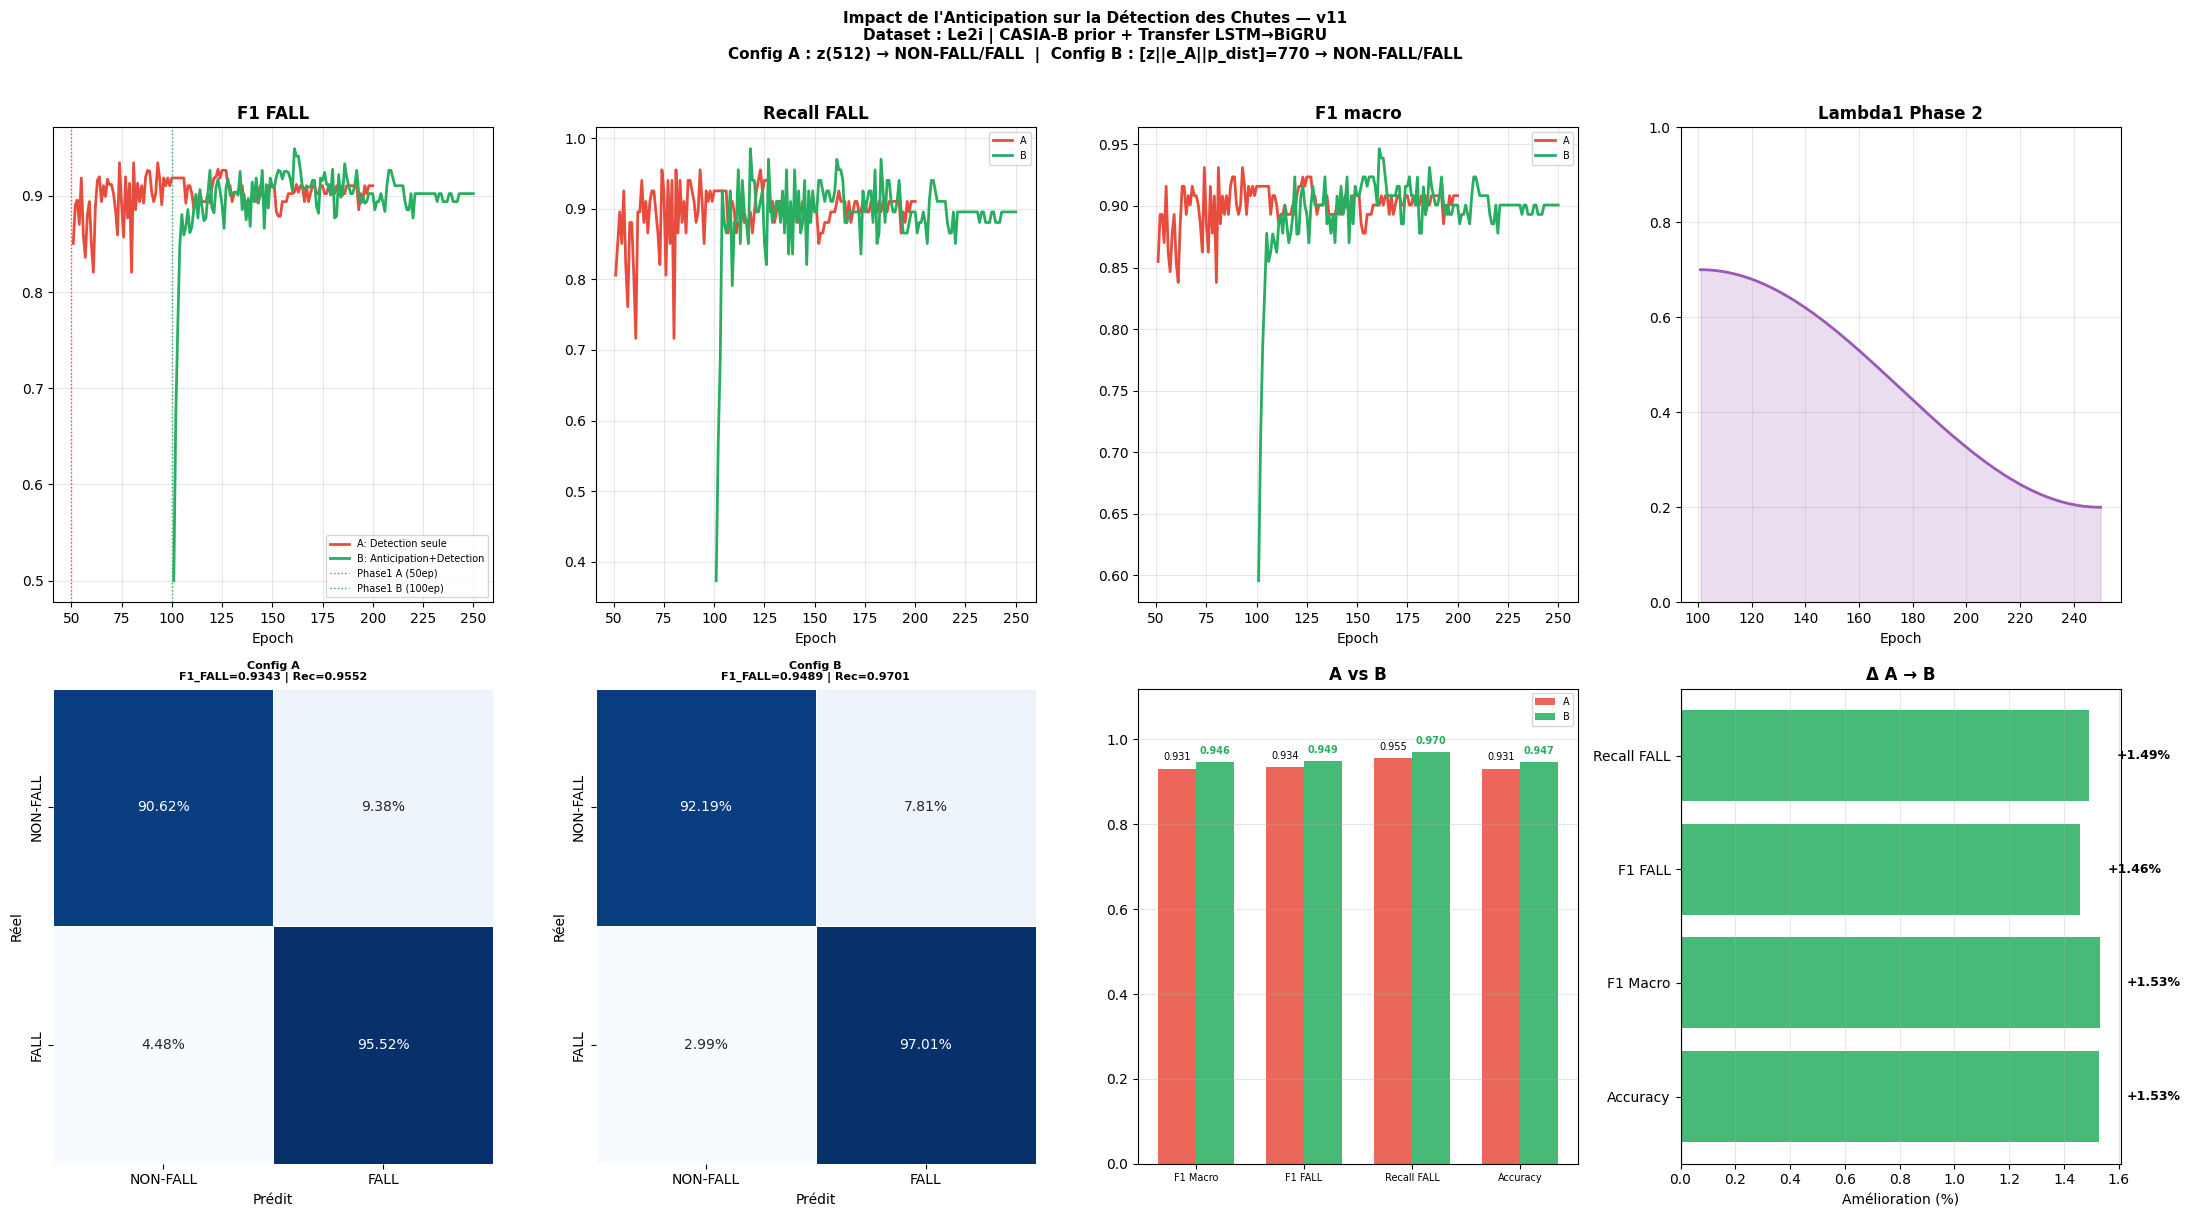

✅ Sauvegardé : /content/results_v11.png


In [20]:
# ============================================================
# CELL 15 — Visualisations
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import confusion_matrix, f1_score

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_NAMES = ['NON-FALL', 'FALL']
CA, CB      = '#E74C3C', '#27AE60'
EPOCHS_P1_A = 50
EPOCHS_P1_B = 100

fig = plt.figure(figsize=(22, 12))
fig.patch.set_facecolor('white')

# 1. F1 FALL
ax1 = fig.add_subplot(2, 4, 1)
epA = [h['epoch'] for h in history_A]
epB = [h['epoch'] for h in history_B]
ax1.plot(epA, [h['f1_fall'] for h in history_A],
          color=CA, lw=2, label='A: Detection seule')
ax1.plot(epB, [h['f1_fall'] for h in history_B],
          color=CB, lw=2, label='B: Anticipation+Detection')
ax1.axvline(EPOCHS_P1_A, color=CA, ls=':', lw=1, label=f'Phase1 A ({EPOCHS_P1_A}ep)')
ax1.axvline(EPOCHS_P1_B, color=CB, ls=':', lw=1, label=f'Phase1 B ({EPOCHS_P1_B}ep)')
ax1.set_title('F1 FALL', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.legend(fontsize=7); ax1.grid(alpha=0.3)

# 2. Recall FALL
ax2 = fig.add_subplot(2, 4, 2)
ax2.plot(epA, [h['recall_fall'] for h in history_A],
          color=CA, lw=2, label='A')
ax2.plot(epB, [h['recall_fall'] for h in history_B],
          color=CB, lw=2, label='B')
ax2.set_title('Recall FALL', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.legend(fontsize=7); ax2.grid(alpha=0.3)

# 3. F1 macro
ax3 = fig.add_subplot(2, 4, 3)
ax3.plot(epA, [h['val_f1'] for h in history_A],
          color=CA, lw=2, label='A')
ax3.plot(epB, [h['val_f1'] for h in history_B],
          color=CB, lw=2, label='B')
ax3.set_title('F1 macro', fontweight='bold')
ax3.set_xlabel('Epoch'); ax3.legend(fontsize=7); ax3.grid(alpha=0.3)

# 4. Lambda progressif
ax4 = fig.add_subplot(2, 4, 4)
ax4.plot(epB, [h['lambda1'] for h in history_B],
          color='#9B59B6', lw=2)
ax4.fill_between(epB, [h['lambda1'] for h in history_B],
                  alpha=0.2, color='#9B59B6')
ax4.set_title('Lambda1 Phase 2', fontweight='bold')
ax4.set_xlabel('Epoch'); ax4.set_ylim(0, 1); ax4.grid(alpha=0.3)

# 5-6. Matrices de confusion
def get_cm(ckpt, model, loader, is_B):
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    p, t = [], []
    with torch.no_grad():
        for xb, _, yd in loader:
            xb, yd = xb.to(DEVICE), yd.to(DEVICE)
            out = model(xb)
            ld  = out[1] if is_B else out
            p.extend(ld.argmax(1).cpu().numpy())
            t.extend(yd.cpu().numpy())
    return confusion_matrix(t, p), np.array(t), np.array(p)

for idx, (tag, name, ckpt, mdl, is_B) in enumerate([
    ('A', 'Detection seule',        ckpt_A, model_A, False),
    ('B', 'Anticipation+Detection', ckpt_B, model_B, True)
]):
    ax_cm = fig.add_subplot(2, 4, 5 + idx)
    cm, t, p = get_cm(ckpt, mdl, val_ld, is_B)
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax_cm, cbar=False, linewidths=0.5)
    f1f  = f1_score(t, p, pos_label=1, average='binary', zero_division=0)
    recf = (p[t==1]==1).mean() if (t==1).sum() > 0 else 0
    ax_cm.set_title(f'Config {tag}\nF1_FALL={f1f:.4f} | Rec={recf:.4f}',
                    fontweight='bold', fontsize=8)
    ax_cm.set_xlabel('Prédit'); ax_cm.set_ylabel('Réel')

# 7. Barplot
ax7 = fig.add_subplot(2, 4, 7)
metrics = ['F1 Macro', 'F1 FALL', 'Recall FALL', 'Accuracy']
vA = [ckpt_A['val_f1'], ckpt_A['f1_fall'],
      ckpt_A['recall_fall'], ckpt_A['val_acc']]
vB = [ckpt_B['val_f1'], ckpt_B['f1_fall'],
      ckpt_B['recall_fall'], ckpt_B['val_acc']]
x, w = np.arange(len(metrics)), 0.35
ax7.bar(x - w/2, vA, w, label='A', color=CA, alpha=0.85)
ax7.bar(x + w/2, vB, w, label='B', color=CB, alpha=0.85)
ax7.set_xticks(x); ax7.set_xticklabels(metrics, fontsize=7)
ax7.set_ylim(0, 1.12); ax7.legend(fontsize=7)
ax7.set_title('A vs B', fontweight='bold')
ax7.grid(axis='y', alpha=0.3)
for xi, (a, b) in enumerate(zip(vA, vB)):
    clr = CB if b >= a else CA
    ax7.text(xi - w/2, a + 0.02, f'{a:.3f}',
              ha='center', fontsize=7, color='black')
    ax7.text(xi + w/2, b + 0.02, f'{b:.3f}',
              ha='center', fontsize=7, fontweight='bold', color=clr)

# 8. Delta A → B
d_f1   = ckpt_B['val_f1']      - ckpt_A['val_f1']
d_fall = ckpt_B['f1_fall']     - ckpt_A['f1_fall']
d_rec  = ckpt_B['recall_fall'] - ckpt_A['recall_fall']
d_acc  = ckpt_B['val_acc']     - ckpt_A['val_acc']

ax8    = fig.add_subplot(2, 4, 8)
dvals  = [d_acc, d_f1, d_fall, d_rec]
dlbls  = ['Accuracy', 'F1 Macro', 'F1 FALL', 'Recall FALL']
clrs   = [CB if d > 0 else CA for d in dvals]
bars   = ax8.barh(dlbls, [d * 100 for d in dvals],
                   color=clrs, alpha=0.85)
ax8.axvline(0, color='black', lw=0.8)
ax8.set_xlabel('Amélioration (%)')
ax8.set_title('Δ A → B', fontweight='bold')
for bar, d in zip(bars, dvals):
    ax8.text(bar.get_width() + 0.1,
              bar.get_y() + bar.get_height() / 2,
              f'{d*100:+.2f}%', va='center',
              fontsize=9, fontweight='bold')
ax8.grid(axis='x', alpha=0.3)

plt.suptitle(
    'Impact de l\'Anticipation sur la Détection des Chutes — v11\n'
    'Dataset : Le2i | CASIA-B prior + Transfer LSTM→BiGRU\n'
    'Config A : z(512) → NON-FALL/FALL  |  '
    'Config B : [z||e_A||p_dist]=770 → NON-FALL/FALL',
    fontsize=11, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('/content/results_v11.png', dpi=200, bbox_inches='tight')
plt.show()
print('✅ Sauvegardé : /content/results_v11.png')

In [22]:
# ============================================================
# CELL 16 — Lead Time + Rapport final
# ============================================================
import numpy as np
import torch
from sklearn.metrics import classification_report

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_NAMES = ['NON-FALL', 'FALL']
FPS_LE2I    = 25
WINDOW_SIZE = 15

def extract_features(kp_seq):
    xy         = kp_seq[:, :, :2].copy().astype(np.float32)
    hip_center = (xy[:, 11, :] + xy[:, 12, :]) / 2.0
    rel        = xy - hip_center[:, np.newaxis, :]
    torso_h    = np.linalg.norm(
        xy[:, 0, :] - hip_center, axis=1, keepdims=True)
    torso_h    = np.where(torso_h < 1e-6, 1.0, torso_h)
    rel        = rel / torso_h[:, np.newaxis, :]
    return rel.reshape(len(kp_seq), -1).astype(np.float32)

print('  LEAD TIME — Config B (Le2i)')
print('=' * 55)

ckpt_B_ld = torch.load('/content/model_B.pth',
                        map_location=DEVICE, weights_only=False)
model_B.load_state_dict(ckpt_B_ld['model_state'])
model_B.eval()

lead_times = []
alerted    = 0
total_fall = 0

with torch.no_grad():
    for sample in labeled_data:
        if not sample['is_fall']: continue
        kp    = sample['keypoints']
        l_det = sample['labels_det']
        T     = len(kp)
        total_fall += 1
        if T < WINDOW_SIZE + 1: continue

        feats = extract_features(kp)
        wins, ends = [], []
        for s in range(0, T - WINDOW_SIZE):
            e = s + WINDOW_SIZE
            wins.append(feats[s:e])
            ends.append(e - 1)

        xb = torch.tensor(np.array(wins),
                           dtype=torch.float32).to(DEVICE)

        # Traitement par batch
        p_pf_all = []
        for i in range(0, len(xb), 64):
            _, _, p_dist = model_B(xb[i:i+64])
            # p_dist shape : (B, 2) — prendre col 1 = PRE-FALL prob
            p_pf_all.append(p_dist[:, 1].cpu().numpy())
        p_pf = np.concatenate(p_pf_all)   # shape : (T,) — 1D ✅

        first_alert = next(
            (i for i, p in enumerate(p_pf) if float(p) > 0.5), None)
        first_fall  = next(
            (i for i, l in enumerate(l_det) if int(l) == 1), None)

        if first_alert is not None and first_fall is not None:
            lead = first_fall - ends[first_alert]
            if lead > 0:
                lead_times.append(lead)
                alerted += 1

print(f'  Séquences fall    : {total_fall}')
print(f'  Alertes précoces  : {alerted}')
print(f'  Taux              : {alerted/max(total_fall,1)*100:.1f}%')
if lead_times:
    arr = np.array(lead_times)
    print(f'  Lead time moyen   : {arr.mean()/FPS_LE2I:.3f}s')
    print(f'  Lead time médiane : {np.median(arr)/FPS_LE2I:.3f}s')
    print(f'  Lead time max     : {arr.max()/FPS_LE2I:.3f}s')

# Rapports de classification
print('\n' + '=' * 62)
for tag, ckpt, mdl, is_B in [
    ('A', ckpt_A, model_A, False),
    ('B', ckpt_B, model_B, True)
]:
    mdl.load_state_dict(ckpt['model_state'])
    _, _, _, _, p, t = evaluate(mdl, val_ld, is_B)
    print(f'\n📊 Config {tag} :')
    print(classification_report(
        t, p, target_names=CLASS_NAMES, zero_division=0))

# Récupérer les deltas depuis Cell 14
d_fall = ckpt_B['f1_fall']     - ckpt_A['f1_fall']
d_rec  = ckpt_B['recall_fall'] - ckpt_A['recall_fall']
h1     = d_fall > 0 or d_rec > 0
lead_s = np.mean(lead_times) / FPS_LE2I if lead_times else 0

print('\n' + '=' * 62)
print('SYNTHÈSE — THÈSE v11 (Le2i)')
print('=' * 62)
print(f"""
QUESTION : L'anticipation améliore-t-elle la détection ?
RÉPONSE  : {"OUI ✅" if h1 else "PAS ENCORE ❌"}

RÉSULTATS :
  ΔF1_FALL     = {d_fall*100:+.2f}%
  ΔRecall_FALL = {d_rec*100:+.2f}%
  Lead time    = {lead_s:.3f}s ({alerted}/{total_fall} chutes alertées)

CONFIG A : F1={ckpt_A['val_f1']:.4f} | F1_FALL={ckpt_A['f1_fall']:.4f} | Rec={ckpt_A['recall_fall']:.4f}
CONFIG B : F1={ckpt_B['val_f1']:.4f} | F1_FALL={ckpt_B['f1_fall']:.4f} | Rec={ckpt_B['recall_fall']:.4f}
""")

from google.colab import files
try:
    files.download('/content/results_v11.png')
except Exception:
    print('Téléchargement manuel : /content/results_v11.png')

  LEAD TIME — Config B (Le2i)
  Séquences fall    : 96
  Alertes précoces  : 92
  Taux              : 95.8%
  Lead time moyen   : 1.623s
  Lead time médiane : 0.920s
  Lead time max     : 16.840s


📊 Config A :
              precision    recall  f1-score   support

    NON-FALL       0.95      0.91      0.93        64
        FALL       0.91      0.96      0.93        67

    accuracy                           0.93       131
   macro avg       0.93      0.93      0.93       131
weighted avg       0.93      0.93      0.93       131


📊 Config B :
              precision    recall  f1-score   support

    NON-FALL       0.97      0.92      0.94        64
        FALL       0.93      0.97      0.95        67

    accuracy                           0.95       131
   macro avg       0.95      0.95      0.95       131
weighted avg       0.95      0.95      0.95       131


SYNTHÈSE — THÈSE v11 (Le2i)

QUESTION : L'anticipation améliore-t-elle la détection ?
RÉPONSE  : OUI ✅

RÉSULTATS :
  ΔF

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
# ============================================================
# CELL 19B — Threshold tuning pour réduire les faux positifs
# ============================================================
from sklearn.metrics import precision_recall_curve

ckpt_B_best = torch.load('/content/model_B.pth',
                          map_location=DEVICE, weights_only=False)
model_B.load_state_dict(ckpt_B_best['model_state'])
model_B.eval()

probs, labels = [], []
with torch.no_grad():
    for xb, _, yd in val_ld:
        xb = xb.to(DEVICE)
        _, ld, _ = model_B(xb)
        p_fall = torch.softmax(ld, dim=1)[:, 1].cpu().numpy()
        probs.extend(p_fall)
        labels.extend(yd.numpy())

precisions, recalls, thresholds = precision_recall_curve(labels, probs)

print('Seuil | Precision | Recall')
print('-' * 35)
for p, r, t in zip(precisions, recalls, thresholds):
    if r >= 0.95:
        print(f'{t:.3f} | {p:.3f}     | {r:.3f}')

Seuil | Precision | Recall
-----------------------------------
0.000 | 0.511     | 1.000
0.000 | 0.515     | 1.000
0.000 | 0.519     | 1.000
0.000 | 0.523     | 1.000
0.000 | 0.532     | 1.000
0.000 | 0.536     | 1.000
0.000 | 0.540     | 1.000
0.000 | 0.545     | 1.000
0.000 | 0.549     | 1.000
0.000 | 0.554     | 1.000
0.000 | 0.558     | 1.000
0.000 | 0.563     | 1.000
0.000 | 0.568     | 1.000
0.000 | 0.573     | 1.000
0.000 | 0.578     | 1.000
0.000 | 0.583     | 1.000
0.000 | 0.588     | 1.000
0.000 | 0.593     | 1.000
0.000 | 0.598     | 1.000
0.000 | 0.604     | 1.000
0.000 | 0.609     | 1.000
0.000 | 0.615     | 1.000
0.000 | 0.620     | 1.000
0.000 | 0.626     | 1.000
0.000 | 0.632     | 1.000
0.000 | 0.638     | 1.000
0.000 | 0.644     | 1.000
0.000 | 0.650     | 1.000
0.001 | 0.657     | 1.000
0.001 | 0.663     | 1.000
0.001 | 0.670     | 1.000
0.001 | 0.677     | 1.000
0.001 | 0.684     | 1.000
0.002 | 0.691     | 1.000
0.002 | 0.698     | 1.000
0.003 | 0.705     | 1.000
0

In [25]:
probs = np.array(probs)
labels = np.array(labels)
fp_mask = (probs >= 0.5) & (labels == 0)
print(f'{fp_mask.sum()} faux positifs sur {(labels==0).sum()} NON-FALL')

5 faux positifs sur 64 NON-FALL


In [26]:
# ============================================================
# CELL 19C — Identifier les vidéos responsables des faux positifs
# ============================================================

# 1) Reconstruire les fenêtres "brutes" (même code, même ordre déterministe)
X_raw, ya_raw, yd_raw = build_windows(labeled_data)

# 2) Suivre le nom de vidéo pour chaque fenêtre brute (même boucle que build_windows)
src_raw = []
for s in labeled_data:
    kp = s['keypoints']
    T  = len(kp)
    if T < WINDOW_SIZE:
        continue
    n_windows = len(range(0, T - WINDOW_SIZE + 1, STRIDE_LE2I))
    src_raw.extend([s['seq_name']] * n_windows)
src_raw = np.array(src_raw)
assert len(src_raw) == len(X_raw), "mismatch — vérifie STRIDE_LE2I/WINDOW_SIZE"

# 3) Reproduire EXACTEMENT le même équilibrage 1:1 (même SEED => mêmes indices)
idx_nf  = np.where(yd_raw == 0)[0]
idx_f   = np.where(yd_raw == 1)[0]
n_min   = min(len(idx_nf), len(idx_f))
np.random.seed(SEED)
idx_all = np.random.permutation(
    np.concatenate([
        np.random.choice(idx_nf, n_min, replace=False),
        np.random.choice(idx_f,  n_min, replace=False)
    ])
)
src_balanced = src_raw[idx_all]   # aligné avec X_le2i / ds

# 4) Récupérer les noms de vidéo correspondant aux fenêtres de val_ld
#    (val_u.indices pointe dans ds, dans le MÊME ordre que val_ld puisque shuffle=False)
val_src_names = src_balanced[val_u.indices]

# 5) Croiser avec les faux positifs déjà calculés (probs, labels de la cellule précédente)
probs  = np.array(probs)
labels = np.array(labels)
fp_mask = (probs >= 0.5) & (labels == 0)

print(f'{fp_mask.sum()} faux positifs sur {(labels==0).sum()} NON-FALL\n')
print('Vidéos responsables des faux positifs :')
fp_videos = val_src_names[fp_mask]
for name, count in zip(*np.unique(fp_videos, return_counts=True)):
    print(f'  {name} : {count} fenêtre(s) mal classée(s)')

Building windows: 100%|██████████| 130/130 [00:00<00:00, 8348.92it/s]

✅ Fenêtres brutes : (5124, 15, 34)
   NON-FALL   : 4,796 (93.6%)
   FALL       : 328 (6.4%)
5 faux positifs sur 64 NON-FALL

Vidéos responsables des faux positifs :
  video (16) : 1 fenêtre(s) mal classée(s)
  video (20) : 1 fenêtre(s) mal classée(s)
  video (57) : 1 fenêtre(s) mal classée(s)
  video (63) : 1 fenêtre(s) mal classée(s)
  video (68) : 1 fenêtre(s) mal classée(s)


In [28]:
# ============================================================
# CELL 19D — Vérifier si les FP sont isolés temporellement
# ============================================================
preds = (probs >= 0.5).astype(int)

# indices des FP dans val_ld (dans l'ordre du DataLoader)
val_indices_ordered = np.array(val_u.indices)  # même ordre que val_ld
fp_positions = np.where(fp_mask)[0]  # position dans val_ld

for pos in fp_positions:
    name = val_src_names[pos]
    print(f'\n--- {name} (position {pos} dans val_ld) ---')
    print(f'  Prédiction : {preds[pos]} (proba FALL={probs[pos]:.3f}) | Vrai label : NON-FALL')


--- video (20) (position 17 dans val_ld) ---
  Prédiction : 1 (proba FALL=0.924) | Vrai label : NON-FALL

--- video (63) (position 56 dans val_ld) ---
  Prédiction : 1 (proba FALL=0.977) | Vrai label : NON-FALL

--- video (68) (position 65 dans val_ld) ---
  Prédiction : 1 (proba FALL=0.773) | Vrai label : NON-FALL

--- video (16) (position 103 dans val_ld) ---
  Prédiction : 1 (proba FALL=0.781) | Vrai label : NON-FALL

--- video (57) (position 106 dans val_ld) ---
  Prédiction : 1 (proba FALL=0.729) | Vrai label : NON-FALL


In [29]:
# ============================================================
# CELL 19E — Inspection temporelle des vidéos responsables des FP
# ============================================================
fp_video_names = ['video (16)', 'video (20)', 'video (57)', 'video (63)', 'video (68)']

model_B.eval()
for name in fp_video_names:
    matches = [s for s in labeled_data if s['seq_name'] == name]
    print(f'\n=== {name} — {len(matches)} correspondance(s) trouvée(s) ===')
    if len(matches) > 1:
        print('  ⚠️ Collision de nom possible entre plusieurs salles !')

    for s in matches:
        kp = s['keypoints']
        T  = len(kp)
        if T < WINDOW_SIZE:
            print('  (trop courte pour fenêtrer)')
            continue
        feats = extract_features(kp)
        wins = [feats[st:st+WINDOW_SIZE] for st in range(0, T - WINDOW_SIZE + 1)]
        xb = torch.tensor(np.array(wins), dtype=torch.float32).to(DEVICE)

        preds_seq, probs_seq = [], []
        with torch.no_grad():
            for i in range(0, len(xb), 64):
                _, ld, _ = model_B(xb[i:i+64])
                p = torch.softmax(ld, dim=1)[:, 1]
                preds_seq.append(ld.argmax(1).cpu().numpy())
                probs_seq.append(p.cpu().numpy())
        preds_seq = np.concatenate(preds_seq)
        probs_seq = np.concatenate(probs_seq)

        is_fall_vid = s['is_fall']
        n_fp_windows = int((preds_seq == 1).sum())
        print(f'  is_fall={is_fall_vid} | {len(preds_seq)} fenêtres | '
              f'{n_fp_windows} prédites FALL')
        # affiche la séquence de prédictions (0/1) pour voir si isolé ou en rafale
        seq_str = ''.join(str(p) for p in preds_seq)
        print(f'  Séquence : {seq_str}')


=== video (16) — 2 correspondance(s) trouvée(s) ===
  ⚠️ Collision de nom possible entre plusieurs salles !
  is_fall=True | 57 fenêtres | 12 prédites FALL
  Séquence : 000011111111111100000000000000000000000000000000000000000
  is_fall=True | 96 fenêtres | 75 prédites FALL
  Séquence : 111111111111111111111111111111111111111111111111111111111111111111111111111000000000000000000000

=== video (20) — 2 correspondance(s) trouvée(s) ===
  ⚠️ Collision de nom possible entre plusieurs salles !
  is_fall=True | 164 fenêtres | 25 prédites FALL
  Séquence : 00000000000000000000000000000000000000000000000000000000000000000000000000000000111111000000000000000000000000000000011111111111111111110000000000000000000000000000
  is_fall=True | 76 fenêtres | 23 prédites FALL
  Séquence : 0000000000000000000000000001111111111111111111111100000000000000000000000000

=== video (57) — 2 correspondance(s) trouvée(s) ===
  ⚠️ Collision de nom possible entre plusieurs salles !
  is_fall=True | 211 fenêtres |

In [30]:
matches_63 = [s for s in labeled_data if s['seq_name'] == 'video (63)']
s = matches_63[0]
kp = s['keypoints']
feats = extract_features(kp)
wins = [feats[st:st+WINDOW_SIZE] for st in range(0, len(kp) - WINDOW_SIZE + 1)]
xb = torch.tensor(np.array(wins), dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    preds_seq = []
    for i in range(0, len(xb), 64):
        _, ld, _ = model_B(xb[i:i+64])
        preds_seq.append(ld.argmax(1).cpu().numpy())
preds_seq = np.concatenate(preds_seq)
burst_start = np.where(preds_seq == 1)[0][0]
burst_end   = np.where(preds_seq == 1)[0][-1]
# FPS_EXTRACT=10 (Cell 14) -> conversion en secondes dans la vidéo extraite
print(f'Rafale FP : fenêtres {burst_start}-{burst_end} '
      f'≈ {burst_start/10:.1f}s à {(burst_end+WINDOW_SIZE)/10:.1f}s dans la vidéo extraite')

Rafale FP : fenêtres 186-194 ≈ 18.6s à 20.9s dans la vidéo extraite


In [2]:
import kagglehub
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

path_le2i = kagglehub.dataset_download('tuyenldvn/falldataset-imvia')
root = Path(path_le2i)

# Retrouver le chemin exact de la vidéo (attention à la collision de nom —
# cherche parmi toutes les salles, is_fall=False donc c'est un ADL)
candidates = sorted(root.rglob('video (63).avi')) + sorted(root.rglob('video (63).AVI'))
print('Candidats trouvés :', [str(c.relative_to(root)) for c in candidates])

Candidats trouvés : ['Coffee_room_02/Coffee_room_02/Videos/video (63).avi']
